In [1]:
## TO RUN ON THE CLOUD 

## preprocessed the data before starting the slide
## import embeddings <s
import os

# Define the URI to point to your manual process
os.environ["FIFTYONE_DATABASE_URI"] = "mongodb://localhost:44123"

import fiftyone as fo

# Verify connection
print(fo.core.odm.database.get_db_conn()) 


You are running the oldest supported major version of MongoDB. Please refer to https://deprecation.voxel51.com for deprecation notices. You can suppress this exception by setting your `database_validation` config parameter to `False`. See https://docs.voxel51.com/user_guide/config.html#configuring-a-mongodb-connection for more information
Database(MongoClient(host=['localhost:44123'], document_class=dict, tz_aware=False, connect=True, appname='fiftyone'), 'fiftyone')


In [2]:
fo.list_datasets()

['FLPLAN',
 'UM_teste',
 'WPonly_1024ov224',
 'flplan200',
 'flplanpatches',
 'nc765',
 'nc765_T1024ov224',
 'nc765_T2048ov224',
 'tiles2048_merged',
 'tiles_merged',
 'tiles_merged_2048',
 'train_nc_wp_T1024ov224',
 'umflplan_T1024ov224',
 'umflplan_T2048ov224',
 'wp125',
 'wp125_T1024ov224',
 'wp125_T2048ov224',
 'wp_final_test']

In [3]:
dataset = fo.load_dataset("wp_final_test")

# Baseline Evaluation

In [17]:
import json 

def center_to_topleft(box):
    """
    Converts a normalized bounding box from
    [cx, cy, w, h] -> [x, y, w, h]
    """
    cx, cy, w, h = box

    x = max(0.0, cx - w / 2)
    y = max(0.0, cy - h / 2)

    # Clip width/height so boxes stay inside the image
    w = min(w, 1.0 - x)
    h = min(h, 1.0 - y)

    return [x, y, w, h]


def load_predictions_from_json(
    dataset,
    json_path,
    pred_field="predictions",
    overwrite=True,
):
    """
    Loads RT-DETR predictions from a JSON file into a FiftyOne dataset.

    Parameters
    ----------
    dataset : fo.Dataset or fo.DatasetView
        Dataset containing the tile images.

    json_path : str
        Path to the prediction JSON.

    pred_field : str
        Name of the field where predictions will be stored.

    overwrite : bool
        Whether to overwrite existing predictions.
    """

    with open(json_path, "r") as f:
        predictions = json.load(f)

    # Build lookup by filepath
    pred_lookup = {
        p["filepath"]: p
        for p in predictions
    }

    loaded = 0
    missing = 0

    with dataset.save_context() as context:

        for sample in dataset:

            pred = pred_lookup.get(sample.filepath)

            if pred is None:
                missing += 1
                continue

            if (
                not overwrite
                and sample.get(pred_field, None) is not None
            ):
                continue

            detections = []

            for det in pred["detections"]:

                detections.append(
                    fo.Detection(
                        label=det["label"],
                        bounding_box=center_to_topleft(
                            det["bounding_box"]
                        ),
                        confidence=det.get("confidence"),
                    )
                )

            sample[pred_field] = fo.Detections(
                detections=detections
            )

            context.save(sample)
            loaded += 1

    print(f"Loaded predictions for {loaded} samples.")
    print(f"Skipped {missing} samples with no matching filepath.")

In [18]:
load_predictions_from_json(
    dataset,
    "/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/models_run/baseline_inference/baseline_test_1_test_predictions.json",
    pred_field="baseline_test1",
)

Loaded predictions for 96 samples.
Skipped 380 samples with no matching filepath.


In [45]:
load_predictions_from_json(
    dataset,
    "/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/models_run/baseline_inference/baseline_test_3_test_predictions.json",
    pred_field="baseline_test3",
)

load_predictions_from_json(
    dataset,
    "/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/models_run/baseline_inference/baseline_test_2_test_predictions.json",
    pred_field="baseline_test2",
)

Loaded predictions for 90 samples.
Skipped 386 samples with no matching filepath.
Loaded predictions for 88 samples.
Skipped 388 samples with no matching filepath.


In [13]:
session = fo.launch_app(dataset, auto=False, port=5151)


Could not connect session, trying again in 10 seconds

Session launched. Run `session.show()` to open the App in a cell output.


In [19]:
session.refresh

<bound method Session.refresh of Dataset:          wp_final_test
Media type:       image
Num samples:      96
Selected samples: 0
Selected labels:  0
Sample:           6a33d1a619d8f6f6ef569371
Session URL:      http://localhost:5151/
View stages:
    1. MatchTags(tags=['test_1'], bool=True, all=False)>

In [14]:
test1_view = dataset.match_tags("test_1")

session.view = test1_view


In [6]:
dataset

Name:        wp_final_test
Media type:  image
Num samples: 476
Persistent:  True
Tags:        []
Sample fields:
    id:                  fiftyone.core.fields.ObjectIdField
    filepath:            fiftyone.core.fields.StringField
    tags:                fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:            fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:          fiftyone.core.fields.DateTimeField
    last_modified_at:    fiftyone.core.fields.DateTimeField
    type_label:          fiftyone.core.fields.StringField
    ground_truth:        fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    region:              fiftyone.core.fields.StringField
    mission_name:        fiftyone.core.fields.StringField
    parent_name:         fiftyone.core.fields.StringField
    gt_field:            fiftyone.core.fields.StringField
    min_area_ratio:      fiftyone.core.fields.FloatField
    n_

In [37]:
test1_view = dataset.match_tags("test_1")

# calculate metrics 
results = test1_view.evaluate_detections(
    "baseline_test1",
    gt_field="ground_truth",
    method="coco",
    eval_key="eval_test1",
    iou=0.5,
    compute_mAP=True,
)

Evaluating detections...
 100% |███████████████████| 96/96 [534.2ms elapsed, 0s remaining, 179.7 samples/s]      
Performing IoU sweep...
 100% |███████████████████| 96/96 [576.3ms elapsed, 0s remaining, 166.6 samples/s]      


In [46]:
test2_view = dataset.match_tags("test_2")
test3_view = dataset.match_tags("test_3")

# calculate metrics 
results2 = test2_view.evaluate_detections(
    "baseline_test2",
    gt_field="ground_truth",
    method="coco",
    eval_key="eval_test2",
    iou=0.5,
    compute_mAP=True,
)

results3 = test3_view.evaluate_detections(
    "baseline_test3",
    gt_field="ground_truth",
    method="coco",
    eval_key="eval_test3",
    iou=0.5,
    compute_mAP=True,
)

Evaluating detections...
 100% |███████████████████| 88/88 [479.4ms elapsed, 0s remaining, 183.6 samples/s]      
Performing IoU sweep...
 100% |███████████████████| 88/88 [503.6ms elapsed, 0s remaining, 174.8 samples/s]      
Evaluating detections...
 100% |███████████████████| 90/90 [560.7ms elapsed, 0s remaining, 160.5 samples/s]      
Performing IoU sweep...
 100% |███████████████████| 90/90 [524.5ms elapsed, 0s remaining, 171.6 samples/s]      


In [ ]:
test1_view = dataset.match_tags("test_1")

# calculate metrics 
results = test1_view.evaluate_detections(
    "baseline_test1",
    gt_field="ground_truth",
    method="coco",
    eval_key="eval_test1",
    iou=0.5,
    compute_mAP=True,
)

### compute the baseline metrics and save in a parquet

In [48]:
import numpy as np 


def _ap_from_pr(recall, precision):
    """All-points AP (area under P-R curve). Single-class -> mAP@iou."""
    r = np.asarray(recall, dtype=float)
    p = np.asarray(precision, dtype=float)
    order = np.argsort(r)
    r, p = r[order], p[order]
    mrec = np.concatenate([[0.0], r, [1.0]])
    mpre = np.concatenate([[p[0] if len(p) else 0.0], p, [0.0]])
    for i in range(len(mpre) - 2, -1, -1):
        mpre[i] = max(mpre[i], mpre[i + 1])
    idx = np.where(mrec[1:] != mrec[:-1])[0]
    return float(np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1]))

    
def _sweep_metrics(res, iou=0.5, n_thresholds=200):
    """
    Confidence sweep at a fixed IoU over a COCODetectionResults object.
    Returns the F1-optimal operating point plus AP@iou / max-recall@iou.
    Positive labels inferred from res.ytrue (handles 'dugong' + 'calf').
    """
    ytrue = np.array(res.ytrue)
    ypred = np.array(res.ypred)
    confs = np.array([v if v is not None else 0.0 for v in res.confs], dtype=float)
    ious  = np.array([v if v is not None else 0.0 for v in res.ious],  dtype=float)

    pos = set(np.unique(ytrue)) - {"(none)"}
    is_pos = lambda a: np.isin(a, list(pos))

    n_gt = int((ypred == "(none)").sum() + (is_pos(ytrue) & is_pos(ypred)).sum())
    pred_mask = ypred != "(none)"

    ts = np.linspace(0.01, 0.99, n_thresholds)
    P = np.zeros(n_thresholds); R = np.zeros(n_thresholds); F = np.zeros(n_thresholds)
    TP = np.zeros(n_thresholds, int); FP = np.zeros(n_thresholds, int); FN = np.zeros(n_thresholds, int)

    for i, t in enumerate(ts):
        mask = pred_mask & (confs >= t)
        tp = int((is_pos(ytrue[mask]) & (ious[mask] >= iou)).sum())
        fp = int((ytrue[mask] == "(none)").sum())
        fn = n_gt - tp
        prec = tp / (tp + fp + 1e-9)
        rec  = tp / (tp + fn + 1e-9)
        P[i], R[i] = prec, rec
        F[i] = 2 * prec * rec / (prec + rec + 1e-9)
        TP[i], FP[i], FN[i] = tp, fp, fn

    b = int(np.argmax(F))
    return {
        "n_gt": n_gt,
        "positive_label": str(sorted(pos)),
        "mAP_50": _ap_from_pr(R, P),
        "mAR_50": float(R.max()),
        "f1_threshold": float(ts[b]),
        "f1": float(F[b]),
        "precision": float(P[b]),
        "recall": float(R[b]),
        "tp": int(TP[b]), "fp": int(FP[b]), "fn": int(FN[b]),
    }

In [50]:
del list 

In [51]:
m1 = _sweep_metrics(results, iou=0.5, n_thresholds=200)
m2 = _sweep_metrics(results2, iou=0.5, n_thresholds=200)
m3 = _sweep_metrics(results3, iou=0.5, n_thresholds=200)

In [52]:
import pandas as pd 
baseline_rows = []
for seed, res, m in [(1, results, m1), (2, results2, m2), (3, results3, m3)]:
    baseline_rows.append({
        "method": "baseline", "partition": 1.0, "partition_pct": 100, "seed": seed,
        "pred_field": f"baseline_test{seed}",
        "mAP_50": m["mAP_50"], "mAP_50_95": float(res.mAP()),
        "mAR": float(res.mAR()), "mAR_50": m["mAR_50"],
        "f1": m["f1"], "precision": m["precision"], "recall": m["recall"],
        "f1_threshold": m["f1_threshold"], "tp": m["tp"], "fp": m["fp"], "fn": m["fn"],
        "n_gt": m["n_gt"], "iou": 0.5, "positive_label": m["positive_label"], "status": "ok",
    })
baseline_df = pd.DataFrame(baseline_rows)
# df = pd.concat([df, pd.DataFrame(baseline_rows)], ignore_index=True)

In [53]:
baseline_df

,method,partition,partition_pct,seed,pred_field,mAP_50,mAP_50_95,mAR,mAR_50,f1,precision,recall,f1_threshold,tp,fp,fn,n_gt,iou,positive_label,status
0,baseline,1.0,100,1,baseline_test1,0.569191,0.372370,0.450000,0.640845,0.649573,0.826087,0.535211,0.088794,76,16,66,142,0.5,[np.str_('dugong')],ok
1,baseline,1.0,100,2,baseline_test2,0.634092,0.367137,0.497345,0.734513,0.702970,0.797753,0.628319,0.093719,71,18,42,113,0.5,[np.str_('dugong')],ok
2,baseline,1.0,100,3,baseline_test3,0.633252,0.458222,0.579630,0.768519,0.670270,0.805195,0.574074,0.098643,62,15,46,108,0.5,[np.str_('dugong')],ok


In [54]:
import os 
baseline_df.to_parquet('/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/results_df/baseline_all_seeds.parquet')

In [36]:
dataset.delete_evaluations()

In [ ]:
dataset.delete_sample_field("baseline_test1")

In [35]:
dataset.first()['ground_truth']['detections']

[<Detection: {
     'id': '6a33d1a219d8f6f6ef569258',
     'attributes': {},
     'tags': [],
     'label': 'dugong',
     'bounding_box': [0.5234375, 0.123046875, 0.06640625, 0.12109375],
     'mask': None,
     'mask_path': None,
     'confidence': None,
     'index': None,
 }>]

In [34]:
for sample in dataset.iter_samples(progress=True):
    list = sample['ground_truth']['detections']
    for ele in list:
        ele['label'] = 'dugong'
    sample.save()

 100% |█████████████████| 476/476 [1.4s elapsed, 0s remaining, 315.5 samples/s]         


In [38]:
results.print_metrics()

accuracy   0.25
precision  0.3
recall     0.64
fscore     0.41
support    142


# Compute df

In [43]:
from importlib import reload

In [44]:
import evaluate
reload(evaluate)

<module 'evaluate' from '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter2_FLPLAN/src/evaluate.py'>

In [41]:
import sys
sys.path.append("/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter2_FLPLAN/src")

# Restart kernel first, then:
from evaluate import sweep_thresholds, plot_sweep, extract_all_metrics

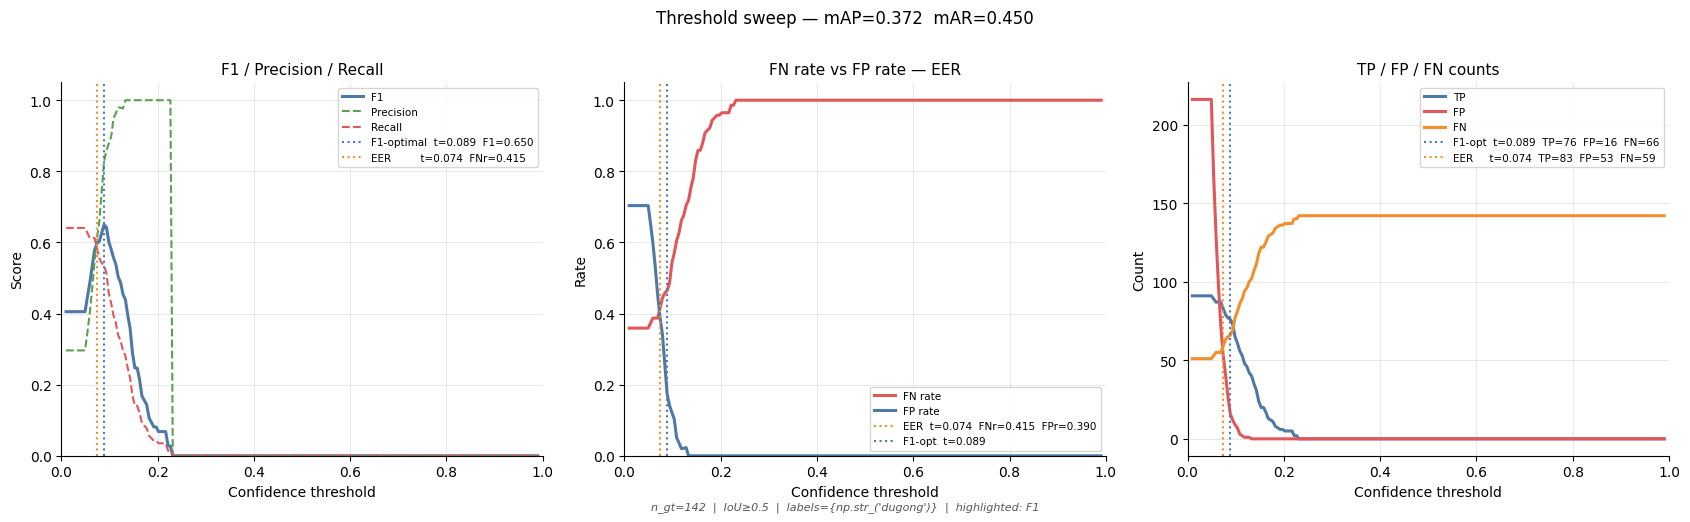

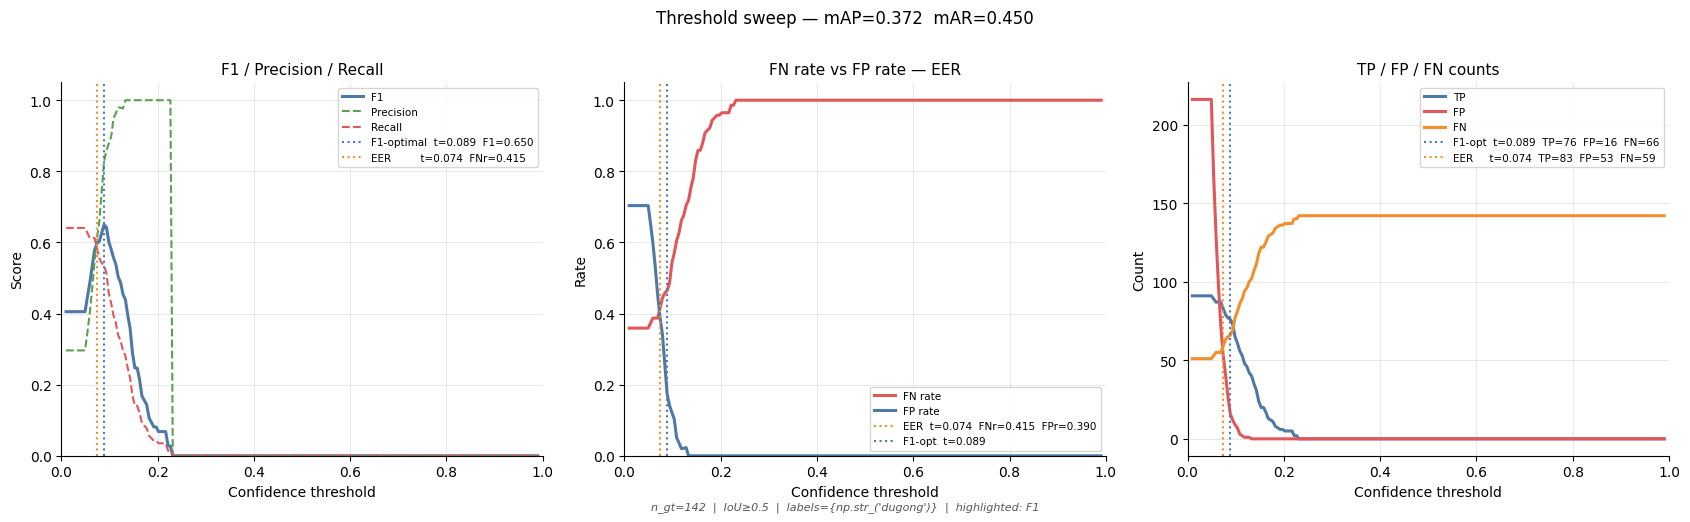

In [42]:
# plot the sweep
plot_sweep(results, method='f1')

In [ ]:
df_seed = extract_all_metrics(
    results_dict = results,
    seed         = 2,
    method       = "f1",       # or "f1" — chosen after inspecting plot_sweep above
    # iou_thresh = None         # reads from res.config.iou automatically
)

# create the df with all inferences

In [4]:

from build_df_result_evaluation import build_results_dataframe

In [8]:
import sys

sys.path.append("/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter2_FLPLAN/src")

from manage_fiftyone import (
    query_inference_jsons,
    remove_prediction_fields,
)

In [9]:
## get list of fields functions
def get_list_of_fields_for_seed(
    dataset,
    seed_term: str,
    verbose:   bool = True,
):
    """
    Return all prediction fields belonging to one seed, split into
    raw / nms / clean (excluding FiftyOne eval book-keeping fields).

    Parameters
    ----------
    dataset   : FiftyOne dataset or view
    seed_term : substring that identifies the seed, e.g. 'seed0', 'SEED63'
    verbose   : print counts

    Returns
    -------
    dict with keys: 'all', 'raw', 'nms', 'clean'
    """
    all_fields  = list(dataset.get_field_schema().keys())
    seed_fields = [f for f in all_fields if seed_term in f]

    raw   = [f for f in seed_fields if f.endswith("_raw")]
    nms   = [f for f in seed_fields if f.endswith("_nms")]
    clean = [
        f for f in seed_fields
        if not any(f.endswith(f"_{s}") for s in ("tp", "fp", "fn", "tn", "iou"))
    ]

    if verbose:
        print(f"seed_term='{seed_term}'  "
              f"total={len(seed_fields)}  "
              f"raw={len(raw)}  nms={len(nms)}  clean={len(clean)}")

    return {"all": seed_fields, "raw": raw, "nms": nms, "clean": clean}




def select_evaluation_list(
    all_op,
    baseline_field: str  = None,
    seed_term:      str  = None,
    deduplicate:    bool = True,
    verbose:        bool = True,
) :
    """
    Build the list of {pred_field, eval_key} dicts ready to pass to
    run_evaluations().

    Parameters
    ----------
    all_op          : list of prediction field names
    nms_or_raw      : 'nms' or 'raw'
    baseline_field  : optional explicit baseline field to append
    seed_term       : seed substring filter
    deduplicate     : remove duplicate pred_fields
    verbose         : print the final list
    """
    from collections import Counter
    def create_eval_key_name(f):
        return f.split('_',1)[1]
    
    eval_list = [
        {"pred_field": f, "eval_key": create_eval_key_name(f)}
        for f in all_op
    ]

    if baseline_field is not None:
        baseline_key = (
            f"baseline_{seed_term}"
            if seed_term else f"baseline_000"
        )
        eval_list.append({"pred_field": baseline_field, "eval_key": baseline_key})

    if deduplicate:
        counts = Counter(d["pred_field"] for d in eval_list)
        dups   = [k for k, v in counts.items() if v > 1]
        if dups and verbose:
            print(f"  WARNING: duplicate pred_fields: {dups}")

        seen: dict[str, dict] = {}
        for item in eval_list:
            key = item["pred_field"]
            if key not in seen:
                seen[key] = item
            elif "baseline" in item["eval_key"]:
                seen[key] = item
        eval_list = list(seen.values())

    if verbose:
        print(f"\nselect_evaluation_list → {len(eval_list)} entries "
              f"(seed='{seed_term}')")
        for e in eval_list:
            print(f"  {e['pred_field']:<55} → {e['eval_key']}")

    return eval_list


In [10]:
## add prediction function
from pathlib import Path
from fiftyone import ViewField as F
import json 

# ── box conversion (your version, + a degenerate-box guard) ───────────────────

def center_to_topleft(box):
    """
    Normalised RT-DETR centre [cx, cy, w, h] -> FiftyOne top-left [x, y, w, h].
    Returns None if the box collapses to zero area after clamping (so the caller
    can skip it -- FiftyOne rejects non-positive width/height).
    """
    cx, cy, w, h = box
    x = max(0.0, cx - w / 2)
    y = max(0.0, cy - h / 2)
    w = min(w, 1.0 - x)
    h = min(h, 1.0 - y)
    if w <= 0.0 or h <= 0.0:
        return None
    return [x, y, w, h]


# ── field name from filename ──────────────────────────────────────────────────

def derive_field_name(json_path, split_on="_rtdetr"):
    """
    Short field name from a prediction JSON filename: everything left of
    `split_on`. '.../NNW_p5_centroid_seed1_rtdetr_..._predictions.json'
    -> 'NNW_p5_centroid_seed1'. Falls back to the full stem if not present.
    """
    stem = Path(json_path).stem
    return stem.split(split_on)[0] if split_on in stem else stem


# ── load ONE json into ONE field ──────────────────────────────────────────────

def load_predictions_from_json(
    dataset,
    json_path,
    pred_field=None,
    split_on="_rtdetr",
    overwrite=True,
    verbose=True,
):
    """
    Load a single prediction JSON into `pred_field` (derived from the filename
    if None). Only samples whose filepath appears in the JSON are touched.

    Returns
    -------
    summary : dict {field, json_tiles, loaded, skipped, missing, detections}
        missing = JSON tiles with no matching sample in `dataset`
        skipped = matched samples left untouched because overwrite=False
    """
    json_path = Path(json_path)
    if pred_field is None:
        pred_field = derive_field_name(json_path, split_on)

    with open(json_path) as f:
        predictions = json.load(f)
    pred_lookup = {p["filepath"]: p for p in predictions}

    # restrict to the tiles this JSON actually predicts on -- fast + debuggable
    view = dataset.match(F("filepath").is_in(list(pred_lookup.keys())))
    n_matched = len(view)

    loaded = skipped = n_det = 0
    for sample in view.iter_samples(autosave=True, progress=verbose):
        if not overwrite and sample.get_field(pred_field) is not None:
            skipped += 1
            continue

        dets = []
        for det in pred_lookup[sample.filepath]["detections"]:
            box = center_to_topleft(det["bounding_box"])
            if box is None:
                continue
            dets.append(
                fo.Detection(
                    label=det["label"],
                    bounding_box=box,
                    confidence=det.get("confidence"),
                )
            )
        sample[pred_field] = fo.Detections(detections=dets)
        loaded += 1
        n_det += len(dets)

    missing = len(pred_lookup) - n_matched
    summary = {
        "field":       pred_field,
        "json_tiles":  len(pred_lookup),
        "loaded":      loaded,
        "skipped":     skipped,
        "missing":     missing,
        "detections":  n_det,
    }
    if verbose:
        flag = "  <-- MISSING TILES" if missing else ""
        print(f"  [{pred_field}] loaded={loaded} skipped={skipped} "
              f"missing={missing} dets={n_det}{flag}")
    return summary


# ── load MANY jsons: one field per file ───────────────────────────────────────

def add_prediction_fields(
    dataset,
    json_paths,
    split_on="_rtdetr",
    overwrite=True,
    verbose=True,
):
    """
    Add several prediction JSONs into the dataset, one field per file.

    Parameters
    ----------
    dataset     : FiftyOne dataset holding the tiles
    json_paths  : list of JSON paths (e.g. from query_inference_jsons)
    split_on    : token used to derive each field name from its filename
    overwrite   : overwrite an existing field of the same name
    verbose     : print a line per file

    Returns
    -------
    summaries : list of per-file dicts (see load_predictions_from_json), each
                also carrying 'json_path' and 'status'. Wrap in
                pd.DataFrame(summaries) for a one-glance overview.
    """
    summaries = []
    for i, jp in enumerate(json_paths):
        jp = Path(jp)
        if verbose:
            print(f"[{i+1}/{len(json_paths)}] {jp.name}")
        try:
            s = load_predictions_from_json(
                dataset, jp, pred_field=None,
                split_on=split_on, overwrite=overwrite, verbose=verbose,
            )
            s["json_path"] = str(jp)
            s["status"] = "ok"
        except Exception as exc:
            print(f"   ERROR: {exc}")
            s = {
                "field": derive_field_name(jp, split_on),
                "json_path": str(jp),
                "status": f"error: {exc}",
            }
        summaries.append(s)

    if verbose:
        ok = [s for s in summaries if s.get("status") == "ok"]
        print(f"\nAdded {len(ok)}/{len(summaries)} fields.")
        for s in summaries:
            if s.get("status") != "ok":
                print(f"  FAILED  {s['field']}: {s['status']}")
            elif s.get("missing"):
                print(f"  WARN    {s['field']}: {s['missing']} JSON tiles "
                      f"had no matching sample in the dataset")
    return summaries

In [11]:
## build results df 
from __future__ import annotations

import json
import re
import warnings
from pathlib import Path
import numpy as np
# ── metric helpers ────────────────────────────────────────────────────────────

def _ap_from_pr(recall, precision):
    """All-points AP (area under P-R curve). Single-class -> mAP@iou."""
    r = np.asarray(recall, dtype=float)
    p = np.asarray(precision, dtype=float)
    order = np.argsort(r)
    r, p = r[order], p[order]
    mrec = np.concatenate([[0.0], r, [1.0]])
    mpre = np.concatenate([[p[0] if len(p) else 0.0], p, [0.0]])
    for i in range(len(mpre) - 2, -1, -1):
        mpre[i] = max(mpre[i], mpre[i + 1])
    idx = np.where(mrec[1:] != mrec[:-1])[0]
    return float(np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1]))


def _sweep_metrics(res, iou=0.5, n_thresholds=200):
    """
    Confidence sweep at a fixed IoU over a COCODetectionResults object.
    Returns the F1-optimal operating point plus AP@iou / max-recall@iou.
    Positive labels inferred from res.ytrue (handles 'dugong' + 'calf').
    """
    ytrue = np.array(res.ytrue)
    ypred = np.array(res.ypred)
    confs = np.array([v if v is not None else 0.0 for v in res.confs], dtype=float)
    ious  = np.array([v if v is not None else 0.0 for v in res.ious],  dtype=float)

    pos = set(np.unique(ytrue)) - {"(none)"}
    pos_arr = np.array(sorted(pos))            # np array, not list() -> immune to
    is_pos = lambda a: np.isin(a, pos_arr)     # a shadowed builtin `list` in the notebook

    n_gt = int((ypred == "(none)").sum() + (is_pos(ytrue) & is_pos(ypred)).sum())
    pred_mask = ypred != "(none)"

    ts = np.linspace(0.01, 0.99, n_thresholds)
    P = np.zeros(n_thresholds); R = np.zeros(n_thresholds); F = np.zeros(n_thresholds)
    TP = np.zeros(n_thresholds, int); FP = np.zeros(n_thresholds, int); FN = np.zeros(n_thresholds, int)

    for i, t in enumerate(ts):
        mask = pred_mask & (confs >= t)
        tp = int((is_pos(ytrue[mask]) & (ious[mask] >= iou)).sum())
        fp = int((ytrue[mask] == "(none)").sum())
        fn = n_gt - tp
        prec = tp / (tp + fp + 1e-9)
        rec  = tp / (tp + fn + 1e-9)
        P[i], R[i] = prec, rec
        F[i] = 2 * prec * rec / (prec + rec + 1e-9)
        TP[i], FP[i], FN[i] = tp, fp, fn

    b = int(np.argmax(F))
    return {
        "n_gt": n_gt,
        "positive_label": str(sorted(pos)),
        "mAP_50": _ap_from_pr(R, P),
        "mAR_50": float(R.max()),
        "f1_threshold": float(ts[b]),
        "f1": float(F[b]),
        "precision": float(P[b]),
        "recall": float(R[b]),
        "tp": int(TP[b]), "fp": int(FP[b]), "fn": int(FN[b]),
    }



_RUN_RE = re.compile(r"(?:^|_)p(\d+)_(.+?)_seed(\d+)(?:_|$)", re.IGNORECASE)

def parse_run_name(path, split_on="_rtdetr"):
    stem = Path(path).stem
    m = _RUN_RE.search(stem)
    if not m:
        return None
    pct = int(m.group(1))
    return {
        "method":        m.group(2).lower(),
        "partition":     pct / 100.0,
        "partition_pct": pct,
        "seed":          int(m.group(3)),
        "field_name":    stem.split(split_on)[0] if split_on in stem else stem,
    }

def build_results_dataframe(
    dataset,
    eval_list,                       # list of {"pred_field","eval_key"} from select_evaluation_list
    gt_field="ground_truth",
    view_tag_fmt="test_{seed}",
    eval_view=None,
    seed=None,                       # used for the view + as fallback seed for unparsable names
    iou=0.5,
    n_thresholds=200,
    classwise=False,
    store_eval_key=False,
    baseline_partition=1.0,          # partition assigned to the baseline row
    cache_path=None,
    verbose=True,
):
    """
    Evaluate prediction fields that ALREADY EXIST in the dataset (no
    reconstruction). One row per field, keyed by (method, partition, seed).

    eval_list : output of select_evaluation_list — dicts with 'pred_field'
                (the FiftyOne field to evaluate) and 'eval_key' (a label).
    seed      : integer seed for the eval view (view_tag_fmt.format(seed=seed))
                and the fallback seed column when a field name can't be parsed
                (e.g. 'baseline_test1'). Required unless eval_view is given.
    """
    def log(msg, level="info"):
        if verbose:
            pre = {"info": "  ", "ok": "OK  ", "warn": "WARN", "err": "ERR "}.get(level, "  ")
            print(f"[{pre}] {msg}")

    if eval_view is None and seed is None:
        raise ValueError("pass either eval_view, or seed (for view_tag_fmt).")

    view = eval_view if eval_view is not None else dataset.match_tags(view_tag_fmt.format(seed=seed))
    n_total = len(view)
    if n_total == 0:
        raise ValueError(f"eval view is empty (tag '{view_tag_fmt.format(seed=seed)}').")

    rows = []
    for i, item in enumerate(eval_list):
        field = item["pred_field"]
        label = item.get("eval_key", field)
        print(f"\n[{i+1}/{len(eval_list)}] {field}")

        ids = parse_run_name(field)              # parses 'NNW_p10_centroid_seed1' style names
        if ids is None:                          # baseline / unparsable -> explicit fallback
            ids = {"method": "baseline", "partition": baseline_partition,
                   "partition_pct": int(round(baseline_partition * 100)),
                   "seed": seed}
            log(f"'{field}' not parseable -> method='baseline', "
                f"partition={baseline_partition}, seed={seed}", "warn")

        try:
            # GT-presence check (ground_truth vs ground_truthv2 trap)
            n_gt_tiles = len(view.exists(gt_field))
            if n_gt_tiles < n_total:
                log(f"{n_total - n_gt_tiles}/{n_total} tiles lack '{gt_field}' "
                    f"-- their predictions count as FP.", "warn")

            res = view.evaluate_detections(
                field, gt_field=gt_field, method="coco", iou=iou,
                classwise=classwise, compute_mAP=True,
                eval_key=(label if store_eval_key else None),
            )
            m = _sweep_metrics(res, iou=iou, n_thresholds=n_thresholds)

            rows.append({
                "method": ids["method"],
                "partition": ids["partition"],
                "partition_pct": ids["partition_pct"],
                "seed": ids["seed"],
                "pred_field": field,
                "eval_key": label,
                "mAP_50": m["mAP_50"],
                "mAP_50_95": float(res.mAP()),
                "mAR": float(res.mAR()),
                "mAR_50": m["mAR_50"],
                "f1": m["f1"], "precision": m["precision"], "recall": m["recall"],
                "f1_threshold": m["f1_threshold"],
                "tp": m["tp"], "fp": m["fp"], "fn": m["fn"],
                "n_gt": m["n_gt"], "iou": iou,
                "positive_label": m["positive_label"], "status": "ok",
            })
            log(f"{ids['method']:<20} p{ids['partition_pct']:<3} seed{ids['seed']}  "
                f"mAP50={m['mAP_50']:.3f}  mAP50-95={res.mAP():.3f}  F1={m['f1']:.3f}", "ok")

        except Exception as exc:
            log(f"failed: {exc}", "err")
            rows.append({"method": ids.get("method"), "partition": ids.get("partition"),
                         "seed": ids.get("seed"), "pred_field": field, "eval_key": label,
                         "status": f"error: {exc}"})

    df = pd.DataFrame(rows)
    _report_completeness(df, verbose)
    if cache_path:
        _cache(df, cache_path, log)
    return df

# ── completeness + caching ────────────────────────────────────────────────────
def _report_completeness(df, verbose=True):
    if not verbose or df.empty:
        return
    ok = df[df["status"] == "ok"] if "status" in df else df
    bad = df[df["status"] != "ok"] if "status" in df else df.iloc[0:0]

    print("\n" + "=" * 60)
    print(f"  Ingest complete: {len(ok)} ok, {len(bad)} failed, {len(df)} total")
    print("=" * 60)

    if len(ok):
        # runs per (method, partition): should equal the number of seeds everywhere
        grid = ok.groupby(["method", "partition"]).size().unstack(fill_value=0)
        print("\n  runs per method x partition (each cell should = #seeds):")
        print(grid.to_string())

        dup = ok.groupby(["method", "partition", "seed"]).size()
        dup = dup[dup > 1]
        if len(dup):
            print("\n  WARNING duplicate (method,partition,seed) rows:")
            print(dup.to_string())

    if len(bad):
        print("\n  failed / skipped runs:")
        for _, r in bad.iterrows():
            print(f"    {r.get('pred_field','?'):<32} {r.get('status')}")

In [12]:
## inference dirs
inference_dir = "/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/models_run/inference"
which_seed = 'seed2'


# ##
# view_test_0 = dataset.load_saved_view('view_test0')
# view_test_1= dataset.load_saved_view('view_test1')
# view_test_2 = dataset.load_saved_view('view_test2')


list_inferences = query_inference_jsons(
    inference_dir= inference_dir,
    seed=which_seed,
    pattern= "*_test_predictions.json",
)

  Found 101 JSON files in 'inference'
  Matched 47 / 101 files
    NNW_p100_random_seed2_rtdetr_0716_2317_test_predictions.json
    NNW_p10_ball_radius_seed2_rtdetr_0715_1409_test_predictions.json
    NNW_p10_ball_radius_seed2_rtdetr_0715_1652_test_predictions.json
    NNW_p10_ball_radius_seed2_rtdetr_0716_0034_test_predictions.json
    NNW_p10_centroid_seed2_rtdetr_0715_1344_test_predictions.json
    NNW_p10_centroid_seed2_rtdetr_0715_1648_test_predictions.json
    NNW_p10_centroid_seed2_rtdetr_0716_0028_test_predictions.json
    NNW_p10_centroid_uniqueness_seed2_rtdetr_0715_1357_test_predictions.json
    NNW_p10_centroid_uniqueness_seed2_rtdetr_0716_0031_test_predictions.json
    NNW_p10_random_seed2_rtdetr_0715_1421_test_predictions.json
    NNW_p10_random_seed2_rtdetr_0716_0038_test_predictions.json
    NNW_p25_ball_radius_seed2_rtdetr_0715_1702_test_predictions.json
    NNW_p25_ball_radius_seed2_rtdetr_0716_0046_test_predictions.json
    NNW_p25_centroid_seed2_rtdetr_0715_1434_tes

In [16]:
new_list_inferences=[]
for lis in list_inferences:
    ss = lis.stem.split('_')
    if "0716" in ss:
        new_list_inferences.append(lis)

In [19]:
list_inferences = new_list_inferences

In [33]:
_RUN_RE = re.compile(r"(?:^|_)p(\d+)_(.+?)_seed(\d+)(?:_|$)", re.IGNORECASE)

def parse_run_name(path, split_on="_rtdetr"):
    stem = Path(path).stem
    m = _RUN_RE.search(stem)
    if not m:
        return None
    pct = int(m.group(1))
    return {
        "method":        m.group(2).lower(),
        "partition":     pct / 100.0,
        "partition_pct": pct,
        "seed":          int(m.group(3)),
        "field_name":    stem.split(split_on)[0] if split_on in stem else stem,
    }

parse_run_name("NNW_p10_centroid_seed2")

{'method': 'centroid',
 'partition': 0.1,
 'partition_pct': 10,
 'seed': 2,
 'field_name': 'NNW_p10_centroid_seed2'}

In [21]:
## REMOVE FIELDS TO MAKE THE DATASET LIGHTHER
# reuse the same parser the ingest uses, so "is this a prediction field?" and
# "how is it keyed?" never drift apart
_RUN_RE = re.compile(r"(?:^|_)p(\d+)_(.+?)_seed(\d+)(?:_|$)", re.IGNORECASE)
 
 
def parse_run_name(name):
    m = _RUN_RE.search(name)
    if not m:
        return None
    pct = int(m.group(1))
    return {"method": m.group(2).lower(), "partition_pct": pct, "seed": int(m.group(3))}
 
 
def remove_prediction_fields(
    dataset,
    seed=None,               # "seed1" | ["seed1","seed2"] | 1 | [1,2]
    partition=None,          # "p10"   | ["p5","p10"]      | 10 | [5,10]
    method=None,             # "centroid" | ["centroid","random"]
    extra_terms=None,        # substrings that must ALL be present
    keep_baseline=True,
    include_eval=False,      # also remove FiftyOne eval bookkeeping (_tp/_fp/_fn/_tn/_iou)
    dry_run=True,
    verbose=True,
):
    """
    Remove prediction fields matching the filters. See module docstring.
 
    Filtering semantics
    -------------------
    - A field is a candidate only if parse_run_name() recognises it (or it is an
      eval-bookkeeping field, when include_eval=True).
    - seed / partition / method: within each filter, ANY value may match (OR);
      across filters, ALL supplied filters must match (AND).
    - Passing NO seed/partition/method filters selects EVERY prediction field
      (still respects keep_baseline and the protected set) -- use with care.
    - extra_terms: every listed substring must be present.
 
    Returns the list of field names deleted (or that would be, in dry_run).
    """
    def _to_list(v):
        if v is None:
            return None
        return [v] if isinstance(v, (str, int)) else list(v)
 
    seeds      = _to_list(seed)
    partitions = _to_list(partition)
    methods    = _to_list(method)
    extras     = _to_list(extra_terms)
 
    # normalise seed/partition tokens to the strings that appear in field names
    def _seed_tok(s):  return s if isinstance(s, str) else f"seed{s}"
    def _part_tok(p):  return p if isinstance(p, str) else f"p{p}"
    seeds      = [_seed_tok(s) for s in seeds] if seeds else None
    partitions = [_part_tok(p) for p in partitions] if partitions else None
 
    _EVAL_SUFFIXES = ("_tp", "_fp", "_fn", "_tn", "_iou")
 
    _PROTECTED = {
        "id", "filepath", "tags", "metadata", "created_at", "last_modified_at",
        "ground_truth", "ground_truthv2", "audit", "roi_grid",
        "region", "mission_name", "parent_name",
        "m_flight", "flight_mission", "name_plot",
        "full_embeddings", "full_emb_umap_dinov3", "v2_full_emb_umap_dinov3",
        "uniqueness_score", "representativeness_score",
        "cluster_label", "cluster_label_8",
        "uniqueness_score_per_cluster", "soft_coverage_score",
        "thumbnail_path",
    }
 
    all_fields = list(dataset.get_field_schema().keys())
 
    def _is_eval_field(name):
        return include_eval and any(name.endswith(s) for s in _EVAL_SUFFIXES)
 
    def _matches(name):
        if name in _PROTECTED:
            return False
 
        parsed = parse_run_name(name)
        # candidate = a recognised prediction field, or an eval bookkeeping field
        if parsed is None and not _is_eval_field(name):
            return False
 
        # for filtering, use the parsed run name if available, else the raw name
        # (eval fields like 'NNW_p10_centroid_seed1_tp' still contain the tokens)
        if seeds and not any(s in name for s in seeds):
            return False
        if partitions and not any(f"_{p}_" in f"_{name}_" for p in partitions):
            return False
        if methods and not any(m in name for m in methods):
            return False
        if extras and not all(e in name for e in extras):
            return False
        return True
 
    to_delete = sorted(f for f in all_fields if _matches(f))
 
    if keep_baseline:
        to_delete = [f for f in to_delete if "baseline" not in f.lower()]
 
    if not to_delete:
        print("  No matching prediction fields found.")
        return []
 
    tag = "DRY RUN --" if dry_run else "DELETING"
    print(f"\n  {tag} {len(to_delete)} fields:")
    for f in to_delete:
        p = parse_run_name(f)
        info = (f"  (method={p['method']} p{p['partition_pct']} seed{p['seed']})"
                if p else "  (eval bookkeeping)")
        print(f"    {f}{info}")
 
    if dry_run:
        print("\n  Dry run -- pass dry_run=False to commit deletion.")
        return to_delete
 
    n_ok = n_err = 0
    for f in to_delete:
        try:
            dataset.delete_sample_field(f)
            n_ok += 1
            if verbose:
                print(f"  deleted  {f}")
        except Exception as e:
            n_err += 1
            print(f"  ERROR deleting '{f}': {e}")
    dataset.save()
    print(f"\n  Done -- deleted {n_ok} fields ({n_err} errors)")
    return to_delete

In [ ]:
#remove already analysed fields to make space in fiftyone mongo
remove_prediction_fields(
    dataset,
    seed="seed3",
    partition=["p5","p10","p40","p50","p75","p100"],
    method=["centroid","centroid_uniqueness","ball_radius","random"],
    dry_run=False
)

In [24]:
## add this list inside the dataset 
add_prediction_fields(
    dataset,
    list_inferences,
    split_on="_rtdetr",
    overwrite=True,
    verbose=True,
)

[1/25] NNW_p100_random_seed2_rtdetr_0716_2317_test_predictions.json
  68% |████████████\------| 60/88 [367.8ms elapsed, 171.7ms remaining, 163.1 samples/s] 

 100% |███████████████████| 88/88 [487.0ms elapsed, 0s remaining, 180.7 samples/s]      
  [NNW_p100_random_seed2] loaded=88 skipped=0 missing=0 dets=132
[2/25] NNW_p10_ball_radius_seed2_rtdetr_0716_0034_test_predictions.json
 100% |███████████████████| 88/88 [401.1ms elapsed, 0s remaining, 219.4 samples/s]      
  [NNW_p10_ball_radius_seed2] loaded=88 skipped=0 missing=0 dets=159
[3/25] NNW_p10_centroid_seed2_rtdetr_0716_0028_test_predictions.json
 100% |███████████████████| 88/88 [490.2ms elapsed, 0s remaining, 179.5 samples/s]      
  [NNW_p10_centroid_seed2] loaded=88 skipped=0 missing=0 dets=276
[4/25] NNW_p10_centroid_uniqueness_seed2_rtdetr_0716_0031_test_predictions.json
 100% |███████████████████| 88/88 [556.8ms elapsed, 0s remaining, 158.0 samples/s]      
  [NNW_p10_centroid_uniqueness_seed2] loaded=88 skipped=0 missing=0 dets=239
[5/25] NNW_p10_random_seed2_rtdetr_0716_0038_test_predictions.json
 100% |███████████████████| 88/88 [635.9ms elapsed, 0s remaining, 138.4 samples

[{'field': 'NNW_p100_random_seed2',
  'json_tiles': 88,
  'loaded': 88,
  'skipped': 0,
  'missing': 0,
  'detections': 132,
  'json_path': '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/models_run/inference/NNW_p100_random_seed2_rtdetr_0716_2317_test_predictions.json',
  'status': 'ok'},
 {'field': 'NNW_p10_ball_radius_seed2',
  'json_tiles': 88,
  'loaded': 88,
  'skipped': 0,
  'missing': 0,
  'detections': 159,
  'json_path': '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/models_run/inference/NNW_p10_ball_radius_seed2_rtdetr_0716_0034_test_predictions.json',
  'status': 'ok'},
 {'field': 'NNW_p10_centroid_seed2',
  'json_tiles': 88,
  'loaded': 88,
  'skipped': 0,
  'missing': 0,
  'detections': 276,
  'json_path': '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/models_run/inference/NNW_p10_centroid_seed2_rtdetr_0716_0028_test_predictions.json',
  'status': 'ok'},
 {'field': 'NNW_p10_centroid_uniqueness_seed2',
  'json_tiles': 88,
  'l

In [25]:
fields_seed = get_list_of_fields_for_seed(dataset, 
                                   seed_term=which_seed)
fields_seed.keys()

seed_term='seed2'  total=25  raw=0  nms=0  clean=25


dict_keys(['all', 'raw', 'nms', 'clean'])

In [26]:
dict_of_input = select_evaluation_list(
    fields_seed["all"],
    seed_term="seed2",
    baseline_field='baseline_test2'
)

dict_of_input


select_evaluation_list → 26 entries (seed='seed2')
  NNW_p100_random_seed2                                   → p100_random_seed2
  NNW_p10_ball_radius_seed2                               → p10_ball_radius_seed2
  NNW_p10_centroid_seed2                                  → p10_centroid_seed2
  NNW_p10_centroid_uniqueness_seed2                       → p10_centroid_uniqueness_seed2
  NNW_p10_random_seed2                                    → p10_random_seed2
  NNW_p25_ball_radius_seed2                               → p25_ball_radius_seed2
  NNW_p25_centroid_seed2                                  → p25_centroid_seed2
  NNW_p25_centroid_uniqueness_seed2                       → p25_centroid_uniqueness_seed2
  NNW_p25_random_seed2                                    → p25_random_seed2
  NNW_p40_ball_radius_seed2                               → p40_ball_radius_seed2
  NNW_p40_centroid_seed2                                  → p40_centroid_seed2
  NNW_p40_centroid_uniqueness_seed2                  

[{'pred_field': 'NNW_p100_random_seed2', 'eval_key': 'p100_random_seed2'},
 {'pred_field': 'NNW_p10_ball_radius_seed2',
  'eval_key': 'p10_ball_radius_seed2'},
 {'pred_field': 'NNW_p10_centroid_seed2', 'eval_key': 'p10_centroid_seed2'},
 {'pred_field': 'NNW_p10_centroid_uniqueness_seed2',
  'eval_key': 'p10_centroid_uniqueness_seed2'},
 {'pred_field': 'NNW_p10_random_seed2', 'eval_key': 'p10_random_seed2'},
 {'pred_field': 'NNW_p25_ball_radius_seed2',
  'eval_key': 'p25_ball_radius_seed2'},
 {'pred_field': 'NNW_p25_centroid_seed2', 'eval_key': 'p25_centroid_seed2'},
 {'pred_field': 'NNW_p25_centroid_uniqueness_seed2',
  'eval_key': 'p25_centroid_uniqueness_seed2'},
 {'pred_field': 'NNW_p25_random_seed2', 'eval_key': 'p25_random_seed2'},
 {'pred_field': 'NNW_p40_ball_radius_seed2',
  'eval_key': 'p40_ball_radius_seed2'},
 {'pred_field': 'NNW_p40_centroid_seed2', 'eval_key': 'p40_centroid_seed2'},
 {'pred_field': 'NNW_p40_centroid_uniqueness_seed2',
  'eval_key': 'p40_centroid_uniqueness

In [27]:
view1 = dataset.match_tags('test_1')
view2 = dataset.match_tags('test_2')
view3 = dataset.match_tags('test_3')

#dataset.save_view("test1",view1)
#dataset.save_view("test2",view2)
#dataset.save_view("test3",view3)

In [31]:
dict_of_input

[{'pred_field': 'NNW_p100_random_seed2', 'eval_key': 'p100_random_seed2'},
 {'pred_field': 'NNW_p10_ball_radius_seed2',
  'eval_key': 'p10_ball_radius_seed2'},
 {'pred_field': 'NNW_p10_centroid_seed2', 'eval_key': 'p10_centroid_seed2'},
 {'pred_field': 'NNW_p10_centroid_uniqueness_seed2',
  'eval_key': 'p10_centroid_uniqueness_seed2'},
 {'pred_field': 'NNW_p10_random_seed2', 'eval_key': 'p10_random_seed2'},
 {'pred_field': 'NNW_p25_ball_radius_seed2',
  'eval_key': 'p25_ball_radius_seed2'},
 {'pred_field': 'NNW_p25_centroid_seed2', 'eval_key': 'p25_centroid_seed2'},
 {'pred_field': 'NNW_p25_centroid_uniqueness_seed2',
  'eval_key': 'p25_centroid_uniqueness_seed2'},
 {'pred_field': 'NNW_p25_random_seed2', 'eval_key': 'p25_random_seed2'},
 {'pred_field': 'NNW_p40_ball_radius_seed2',
  'eval_key': 'p40_ball_radius_seed2'},
 {'pred_field': 'NNW_p40_centroid_seed2', 'eval_key': 'p40_centroid_seed2'},
 {'pred_field': 'NNW_p40_centroid_uniqueness_seed2',
  'eval_key': 'p40_centroid_uniqueness

In [34]:
import pandas as pd 
df = build_results_dataframe(
    dataset,
    dict_of_input,                       # list of {"pred_field","eval_key"} from select_evaluation_list
    gt_field="ground_truth",
    eval_view=view2,
    seed=2,
    iou=0.5,
    n_thresholds=200,
    classwise=False,
    store_eval_key=False,
    baseline_partition=1.0,          # partition assigned to the baseline row
    cache_path=None,
    verbose=True
)


[1/26] NNW_p100_random_seed2
Evaluating detections...
 100% |███████████████████| 88/88 [260.0ms elapsed, 0s remaining, 338.4 samples/s]      
Performing IoU sweep...
 100% |███████████████████| 88/88 [326.9ms elapsed, 0s remaining, 269.2 samples/s]      
[OK  ] random               p100 seed2  mAP50=0.580  mAP50-95=0.358  F1=0.632

[2/26] NNW_p10_ball_radius_seed2
Evaluating detections...
 100% |███████████████████| 88/88 [184.9ms elapsed, 0s remaining, 475.9 samples/s]     
Performing IoU sweep...
 100% |███████████████████| 88/88 [220.4ms elapsed, 0s remaining, 399.2 samples/s]     
[OK  ] ball_radius          p10  seed2  mAP50=0.660  mAP50-95=0.427  F1=0.709

[3/26] NNW_p10_centroid_seed2
Evaluating detections...
 100% |███████████████████| 88/88 [206.1ms elapsed, 0s remaining, 427.0 samples/s]     
Performing IoU sweep...
 100% |███████████████████| 88/88 [269.1ms elapsed, 0s remaining, 327.0 samples/s]      
[OK  ] centroid             p10  seed2  mAP50=0.446  mAP50-95=0.223  F1

In [35]:
df

,method,partition,partition_pct,seed,pred_field,eval_key,mAP_50,mAP_50_95,mAR,mAR_50,...,precision,recall,f1_threshold,tp,fp,fn,n_gt,iou,positive_label,status
0,random,1.00,100,2,NNW_p100_random_seed2,p100_random_seed2,0.579942,0.358341,0.459292,0.681416,...,0.626087,0.637168,0.054322,72,43,41,113,0.5,[np.str_('dugong')],ok
1,ball_radius,0.10,10,2,NNW_p10_ball_radius_seed2,p10_ball_radius_seed2,0.659916,0.427151,0.548673,0.787611,...,0.718182,0.699115,0.064171,79,31,34,113,0.5,[np.str_('dugong')],ok
2,centroid,0.10,10,2,NNW_p10_centroid_seed2,p10_centroid_seed2,0.445921,0.222942,0.531858,0.778761,...,0.534483,0.548673,0.074020,62,54,51,113,0.5,[np.str_('dugong')],ok
3,centroid_uniqueness,0.10,10,2,NNW_p10_centroid_uniqueness_seed2,p10_centroid_uniqueness_seed2,0.533413,0.295837,0.575221,0.814159,...,0.520833,0.663717,0.069095,75,69,38,113,0.5,[np.str_('dugong')],ok
4,random,0.10,10,2,NNW_p10_random_seed2,p10_random_seed2,0.436568,0.210532,0.535398,0.814159,...,0.463855,0.681416,0.059246,77,89,36,113,0.5,[np.str_('dugong')],ok
5,ball_radius,0.25,25,2,NNW_p25_ball_radius_seed2,p25_ball_radius_seed2,0.683723,0.447064,0.573451,0.805310,...,0.702703,0.690265,0.064171,78,33,35,113,0.5,[np.str_('dugong')],ok
6,centroid,0.25,25,2,NNW_p25_centroid_seed2,p25_centroid_seed2,0.476402,0.219196,0.477876,0.778761,...,0.457831,0.672566,0.064171,76,90,37,113,0.5,[np.str_('dugong')],ok
7,centroid_uniqueness,0.25,25,2,NNW_p25_centroid_uniqueness_seed2,p25_centroid_uniqueness_seed2,0.688596,0.411652,0.598230,0.858407,...,0.677966,0.707965,0.069095,80,38,33,113,0.5,[np.str_('dugong')],ok
8,random,0.25,25,2,NNW_p25_random_seed2,p25_random_seed2,0.468726,0.243002,0.519469,0.796460,...,0.459302,0.699115,0.059246,79,93,34,113,0.5,[np.str_('dugong')],ok
9,ball_radius,0.40,40,2,NNW_p40_ball_radius_seed2,p40_ball_radius_seed2,0.654005,0.419061,0.548673,0.778761,...,0.666667,0.690265,0.059246,78,39,35,113,0.5,[np.str_('dugong')],ok


In [36]:
df.to_parquet("/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/models_run/results_df/seed2.parquet")

In [69]:
import re
from pathlib import Path

_RUN_RE = re.compile(r"(?:^|_)p(\d+)_(.+?)_seed(\d+)(?:_|$)", re.IGNORECASE)

def parse_run_name(path, split_on="_rtdetr"):
    stem = Path(path).stem
    m = _RUN_RE.search(stem)
    if not m:
        return None
    pct = int(m.group(1))
    return {
        "method":        m.group(2).lower(),
        "partition":     pct / 100.0,
        "partition_pct": pct,
        "seed":          int(m.group(3)),
        "field_name":    stem.split(split_on)[0] if split_on in stem else stem,
    }

print(parse_run_name("NNW_p100_random_seed1"))

{'method': 'random', 'partition': 1.0, 'partition_pct': 100, 'seed': 1, 'field_name': 'NNW_p100_random_seed1'}


In [32]:
all_fields = list(dataset.get_field_schema().keys())
all_fields

['id',
 'filepath',
 'tags',
 'metadata',
 'created_at',
 'last_modified_at',
 'type_label',
 'ground_truth',
 'region',
 'mission_name',
 'parent_name',
 'gt_field',
 'min_area_ratio',
 'n_boxes_in_tile',
 'n_boxes_written',
 'source_image',
 'tile_name',
 'x_start',
 'y_start',
 'dataset_sr',
 'train_cluster_label',
 'flight_unique',
 'subregion',
 'cluster_train_1',
 'cluster_train_2',
 'cluster_train_3',
 'baseline_test1',
 'eval_test1_tp',
 'eval_test1_fp',
 'eval_test1_fn',
 'baseline_test3',
 'baseline_test2',
 'eval_test2_tp',
 'eval_test2_fp',
 'eval_test2_fn',
 'eval_test3_tp',
 'eval_test3_fp',
 'eval_test3_fn',
 'NNW_p100_random_seed1',
 'NNW_p10_ball_radius_seed1',
 'NNW_p10_centroid_seed1',
 'NNW_p10_centroid_uniqueness_seed1',
 'NNW_p10_random_seed1',
 'NNW_p25_ball_radius_seed1',
 'NNW_p25_centroid_seed1',
 'NNW_p25_centroid_uniqueness_seed1',
 'NNW_p25_random_seed1',
 'NNW_p40_ball_radius_seed1',
 'NNW_p40_centroid_seed1',
 'NNW_p40_centroid_uniqueness_seed1',
 'NNW_p4

In [126]:
session.close()

RuntimeError: Client is not connected

In [ ]:
session = fo.launch_app(view3,port=5151,auto=False)

In [108]:
view = dataset.match(
    F("eval_test1_fn") > 0
)
view

Dataset:     wp_final_test
Media type:  image
Num samples: 46
Sample fields:
    id:                                fiftyone.core.fields.ObjectIdField
    filepath:                          fiftyone.core.fields.StringField
    tags:                              fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:                          fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:                        fiftyone.core.fields.DateTimeField
    last_modified_at:                  fiftyone.core.fields.DateTimeField
    type_label:                        fiftyone.core.fields.StringField
    ground_truth:                      fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    region:                            fiftyone.core.fields.StringField
    mission_name:                      fiftyone.core.fields.StringField
    parent_name:                       fiftyone.core.fields.StringField
  

In [109]:
session.view = view

In [80]:
dataset.list_evaluations()

['eval_test1', 'eval_test2', 'eval_test3']

In [82]:
dataset

Name:        wp_final_test
Media type:  image
Num samples: 476
Persistent:  True
Tags:        []
Sample fields:
    id:                                fiftyone.core.fields.ObjectIdField
    filepath:                          fiftyone.core.fields.StringField
    tags:                              fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:                          fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:                        fiftyone.core.fields.DateTimeField
    last_modified_at:                  fiftyone.core.fields.DateTimeField
    type_label:                        fiftyone.core.fields.StringField
    ground_truth:                      fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    region:                            fiftyone.core.fields.StringField
    mission_name:                      fiftyone.core.fields.StringField
    parent_name:                       

In [86]:
view1.first()

<SampleView: {
    'id': '6a33d1a619d8f6f6ef56935a',
    'media_type': 'image',
    'filepath': '/share/home/e2406743/dataset/tiles_all/umflplan/positive/images/FPLAN_P4P_UM_M48_F1_2025_GSP-697e1055e6795_189__tile_0_2400_t1024_o224.jpg',
    'tags': ['train_0', 'test_1', 'train_2', 'train_3'],
    'metadata': <ImageMetadata: {
        'size_bytes': 66105,
        'mime_type': 'image/jpeg',
        'width': 1024,
        'height': 1024,
        'num_channels': 3,
    }>,
    'created_at': datetime.datetime(2026, 7, 13, 17, 34, 8, 91000),
    'last_modified_at': datetime.datetime(2026, 7, 21, 16, 42, 25, 725000),
    'type_label': 'positive',
    'ground_truth': <Detections: {
        'detections': [
            <Detection: {
                'id': '6a33d1a219d8f6f6ef5692cb',
                'attributes': {},
                'tags': [],
                'label': 'dugong',
                'bounding_box': [0.8193359375, 0.6728515625, 0.06640625, 0.05859375],
                'mask': None,
   

In [97]:

eval_patches = view1.to_evaluation_patches("eval_test1")
fp_patches = eval_patches.match(F("type") == "fn")

fp_patches
#session.view = fp_patches

Dataset:     wp_final_test
Media type:  image
Num patches: 51
Patch fields:
    id:               fiftyone.core.fields.ObjectIdField
    sample_id:        fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    baseline_test1:   fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    crowd:            fiftyone.core.fields.BooleanField
    type:             fiftyone.core.fields.StringField
    iou:              fiftyone.core.fields.FloatField
View stages:
    1. MatchTags(tags=['test_1'], bool=True, all=False)
    2. ToEvaluationPa

In [100]:
dataset

Name:        wp_final_test
Media type:  image
Num samples: 476
Persistent:  True
Tags:        []
Sample fields:
    id:                                fiftyone.core.fields.ObjectIdField
    filepath:                          fiftyone.core.fields.StringField
    tags:                              fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:                          fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:                        fiftyone.core.fields.DateTimeField
    last_modified_at:                  fiftyone.core.fields.DateTimeField
    type_label:                        fiftyone.core.fields.StringField
    ground_truth:                      fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    region:                            fiftyone.core.fields.StringField
    mission_name:                      fiftyone.core.fields.StringField
    parent_name:                       

## Join df and prepare plots

In [37]:
df1 = pd.read_parquet("/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/models_run/results_df/seed1.parquet")
df2 = pd.read_parquet("/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/models_run/results_df/seed2.parquet")
df3 = pd.read_parquet("/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/models_run/results_df/seed3.parquet")


In [38]:
df_join = pd.concat([df1,df2,df3])

In [39]:
df_join.shape

(78, 21)

In [40]:
df_join.head()

,method,partition,partition_pct,seed,pred_field,eval_key,mAP_50,mAP_50_95,mAR,mAR_50,...,precision,recall,f1_threshold,tp,fp,fn,n_gt,iou,positive_label,status
0,random,1.0,100,1,NNW_p100_random_seed1,p100_random_seed1,0.517336,0.302705,0.431690,0.640845,...,0.645161,0.563380,0.059246,80,44,62,142,0.5,[np.str_('dugong')],ok
1,ball_radius,0.1,10,1,NNW_p10_ball_radius_seed1,p10_ball_radius_seed1,0.712466,0.422097,0.557042,0.816901,...,0.813008,0.704225,0.083869,100,23,42,142,0.5,[np.str_('dugong')],ok
2,centroid,0.1,10,1,NNW_p10_centroid_seed1,p10_centroid_seed1,0.661734,0.401353,0.540141,0.767606,...,0.703704,0.669014,0.069095,95,40,47,142,0.5,[np.str_('dugong')],ok
3,centroid_uniqueness,0.1,10,1,NNW_p10_centroid_uniqueness_seed1,p10_centroid_uniqueness_seed1,0.682096,0.412801,0.581690,0.845070,...,0.750000,0.654930,0.078945,93,31,49,142,0.5,[np.str_('dugong')],ok
4,random,0.1,10,1,NNW_p10_random_seed1,p10_random_seed1,0.638274,0.407048,0.543662,0.760563,...,0.623457,0.711268,0.059246,101,61,41,142,0.5,[np.str_('dugong')],ok


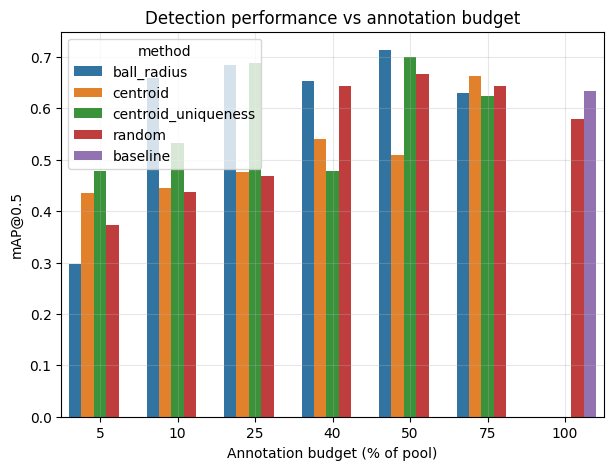

In [ ]:
import seaborn as sns, matplotlib.pyplot as plt

#d = df[df.status == "ok"]

fig, ax = plt.subplots(figsize=(7,5))
sns.barplot(data=d, x="partition_pct", y="mAP_50", hue="method", estimator=np.mean, capsize=.5, ax=ax)
ax.set_xlabel("Annotation budget (% of pool)")
ax.set_ylabel("mAP@0.5")
ax.set_title("Detection performance vs annotation budget")
ax.grid(alpha=.3)

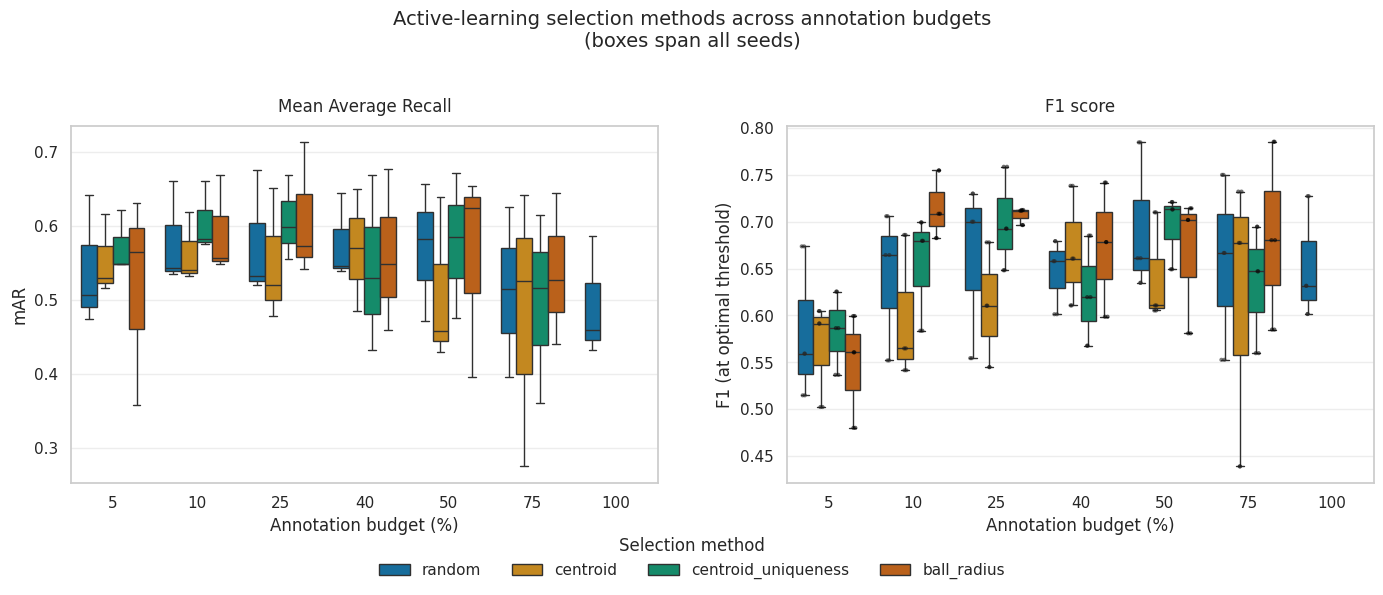

In [61]:
sns.stripplot(data=dat, x="partition_pct", y=col, hue="method",
                  hue_order=order, dodge=True, palette="dark:black",
                  size=3, alpha=.6, legend=False, ax=ax)
fig

In [ ]:
pd.get_option()

<function pandas.get_option(pat: 'str') -> 'Any'>

In [90]:
with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
):
    print(df_join.loc[df_join['seed']==3])

                 method  partition  partition_pct  seed  \
0                random       1.00            100     3   
1           ball_radius       0.10             10     3   
2              centroid       0.10             10     3   
3   centroid_uniqueness       0.10             10     3   
4                random       0.10             10     3   
5           ball_radius       0.25             25     3   
6              centroid       0.25             25     3   
7   centroid_uniqueness       0.25             25     3   
8                random       0.25             25     3   
9           ball_radius       0.40             40     3   
10             centroid       0.40             40     3   
11  centroid_uniqueness       0.40             40     3   
12               random       0.40             40     3   
13          ball_radius       0.50             50     3   
14             centroid       0.50             50     3   
15  centroid_uniqueness       0.50             50     3 

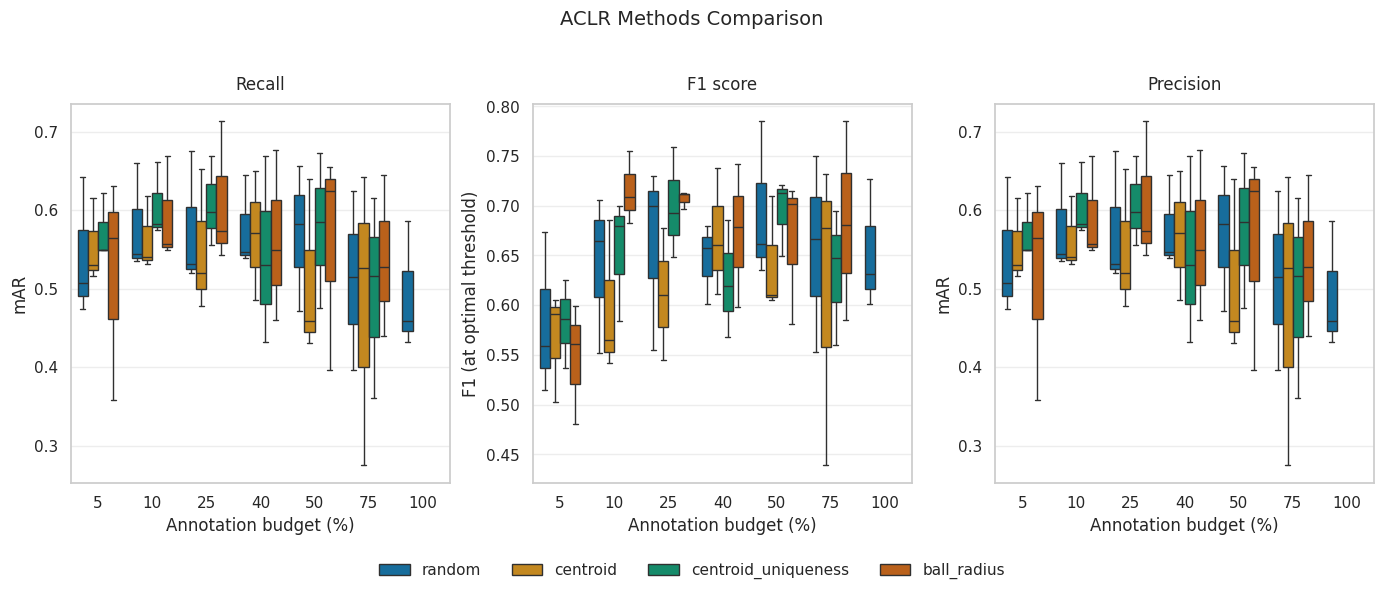

In [77]:

dat = df_join.loc[df_join["method"] != "baseline"].copy()

# fixed method order + palette so colours are consistent across every figure
order = ["random", "centroid", "centroid_uniqueness", "ball_radius"]
palette = dict(zip(order, sns.color_palette("colorblind", len(order))))
dat["method"] = pd.Categorical(dat["method"], categories=order, ordered=True)

sns.set_theme(style="whitegrid", context="notebook")

fig, axes = plt.subplots(1, 3, figsize=(14, 5.5), sharex=True)

specs = [("mAR", "mAR", "Recall"),
         ("f1",  "F1 (at optimal threshold)", "F1 score"),
         ("mAR", "mAR","Precision")]

for ax, (col, ylab, title) in zip(axes, specs):
    sns.boxplot(data=dat, x="partition_pct", y=col, hue="method",
                order=sorted(dat["partition_pct"].unique()),
                hue_order=order, palette=palette,
                width=.75, fliersize=2.5, linewidth=1.0, ax=ax)

    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel("Annotation budget (%)")
    ax.set_ylabel(ylab)
    ax.grid(axis="y", alpha=.35)
    ax.grid(axis="x", visible=False)
    ax.legend_.remove()                      # drop per-axes legends

# one shared legend under both panels
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, #title="Selection method",
           loc="lower center", bbox_to_anchor=(0.5, -0.04),
           ncol=len(order), frameon=False)

fig.suptitle("ACLR Methods Comparison", fontsize=14, y=1.02)
fig.tight_layout()
fig.subplots_adjust(wspace=0.22, bottom=0.16)
# fig.savefig("al_mar_f1.png", dpi=300, bbox_inches="tight")

Text(0.5, 1.0, 'Active-learning uplift over random selection')

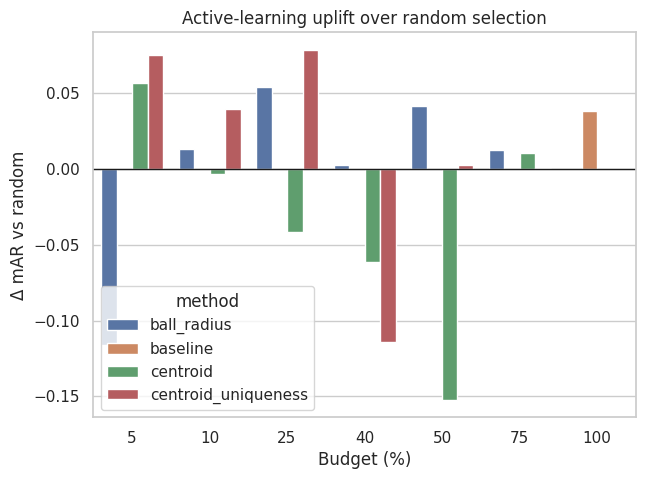

In [68]:
piv = d.pivot_table("mAR", ["partition_pct","seed"], "method")
upl = piv.drop(columns="random").sub(piv["random"], axis=0).reset_index()
upl = upl.melt(["partition_pct","seed"], var_name="method", value_name="uplift")

fig, ax = plt.subplots(figsize=(7,5))
sns.barplot(data=upl, x="partition_pct", y="uplift", hue="method",
            errorbar="sd", ax=ax)
ax.axhline(0, color="k", lw=1)
ax.set_xlabel("Budget (%)"); ax.set_ylabel("Δ mAR vs random")
ax.set_title("Active-learning uplift over random selection")

Text(0.5, 1.0, 'Precision–recall at F1-optimal threshold')

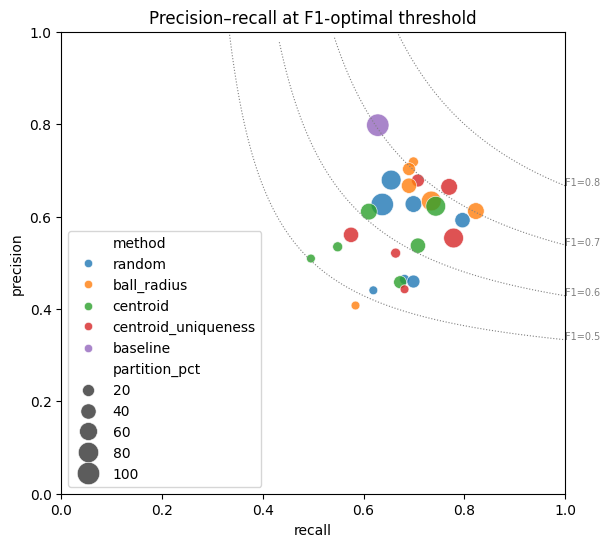

In [ ]:
fig, ax = plt.subplots(figsize=(6.5,6))
sns.scatterplot(data=d, 
                x="recall", 
                y="precision", 
                hue="method",
                size="partition_pct", 
                sizes=(40,260), 
                alpha=.8, 
                ax=ax
                )
for f in [0.5,0.6,0.7,0.8]:                      # iso-F1 contours
    r = np.linspace(0.01,1,200); p = f*r/(2*r-f)
    m = (p>0)&(p<=1); ax.plot(r[m], p[m], ls=":", c="grey", lw=.8)
    if m.any(): ax.annotate(f"F1={f}", (r[m][-1], p[m][-1]), fontsize=7, color="grey")
ax.set_xlim(0,1); ax.set_ylim(0,1); ax.set_title("Precision–recall at F1-optimal threshold")

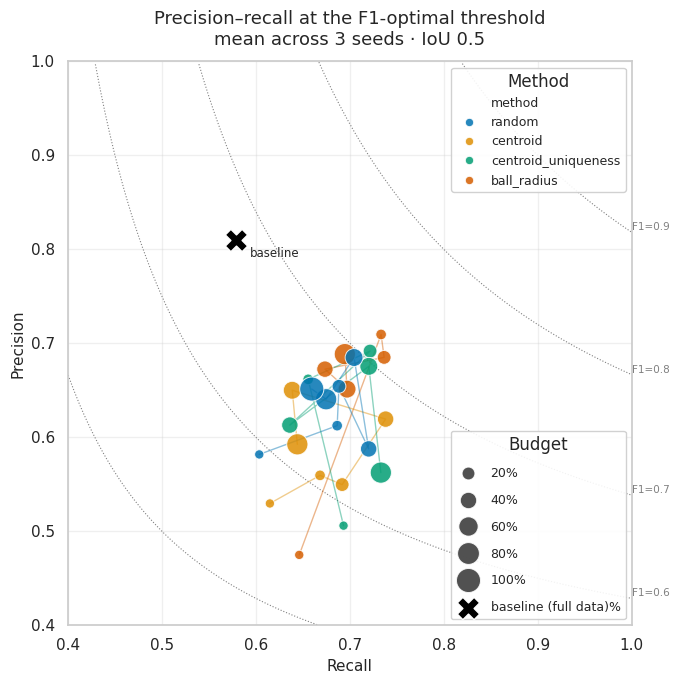

In [76]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

d = df_join[df_join.status == "ok"].copy()

order   = ["random", "centroid", "centroid_uniqueness", "ball_radius"]
palette = dict(zip(order, sns.color_palette("colorblind", len(order))))

# ── mean across seeds, per (method, budget) ──────────────────────────────────
agg = (d.groupby(["method", "partition_pct"], as_index=False)
         .agg(precision=("precision", "mean"),
              recall=("recall", "mean"),
              n_seeds=("seed", "nunique")))

al   = agg[agg.method.isin(order)]
base = agg[agg.method == "baseline"]

sns.set_theme(style="whitegrid", context="notebook")
fig, ax = plt.subplots(figsize=(7.5, 7))

# ── iso-F1 contours first, so points sit on top ──────────────────────────────
for f in [0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    r = np.linspace(0.001, 1, 400)
    p = f * r / (2 * r - f)
    m = (p > 0) & (p <= 1) & (r >= f / 2)
    if not m.any():
        continue
    ax.plot(r[m], p[m], ls=":", c="grey", lw=.8, zorder=1)
    ax.annotate(f"F1={f}", (r[m][-1], p[m][-1]), fontsize=7.5, color="grey",
                ha="left", va="bottom", zorder=1)

# ── AL methods: dot size = budget ────────────────────────────────────────────
sns.scatterplot(data=al, x="recall", y="precision", hue="method",
                size="partition_pct", sizes=(45, 300),
                hue_order=order, palette=palette,
                alpha=.85, edgecolor="white", linewidth=.7,
                ax=ax, zorder=3)

# connect each method's points in budget order -> shows the trajectory
for meth, g in al.sort_values("partition_pct").groupby("method"):
    ax.plot(g.recall, g.precision, color=palette[meth],
            lw=1.0, alpha=.45, zorder=2)

# ── baseline: X marker ───────────────────────────────────────────────────────
if len(base):
    ax.scatter(base.recall, base.precision, marker="X", s=260,
               c="black", edgecolor="white", linewidth=1.0,
               zorder=5, label="baseline (full data)")
    for _, r_ in base.iterrows():
        ax.annotate("baseline", (r_.recall, r_.precision),
                    textcoords="offset points", xytext=(10, -12),
                    fontsize=8.5, fontweight="medium", zorder=5)

# ── legend: split method vs budget ───────────────────────────────────────────
h, l = ax.get_legend_handles_labels()
cut = l.index("partition_pct") if "partition_pct" in l else len(l)
leg1 = ax.legend(h[:cut], l[:cut], title="Method", 
                 loc="upper right", frameon=True, framealpha=.9, fontsize=9)
ax.add_artist(leg1)
if cut < len(l):
    ax.legend(h[cut+1:], [f"{v}%" for v in l[cut+1:]], title="Budget",
              loc="lower right", frameon=True, framealpha=.9,
              fontsize=9, labelspacing=1.1)

ax.set_xlabel("Recall", fontsize=11)
ax.set_ylabel("Precision", fontsize=11)
ax.set_title("Precision–recall at the F1-optimal threshold\n"
             f"mean across {int(agg.n_seeds.max())} seeds · IoU 0.5",
             fontsize=13, pad=12)
ax.set_aspect("equal")
ax.grid(alpha=.3)

# zoom to the populated region (comment out for the full unit square)
pad = .06
ax.set_xlim(0.4, 1.0)
ax.set_ylim(0.4, 1.0)

fig.tight_layout()
# fig.savefig("pr_operating_points.png", dpi=300, bbox_inches="tight")